# Lab01- Cotizaciones Óptimas de un formador de mercado
## Microestructuras y Sistemas de Trading

## Equipo 4
Isabela Torrres Septien Uribe

Jose Emmanuel Flores Cortes


En el siguiente notebook solo encontramos el analisis y las gráficas. SIn embarco la lógica y modelo se encuentra en el src\model.py y en src\plots.py

In [1]:
import numpy as np
from scipy.stats import erlang
from scipy.integrate import quad
import scipy.optimize as opt

In [2]:
So = 19.90 # Precio de referencia
K = 60
Lam = 3.0

pi_i = 0.4 # Prob. informado
pi_l = 0.6 # Prob liquidez


In [3]:
#Definimos función erlang
def f(P):
    return erlang.pdf(P, K, scale=1/Lam)

def prob_ejecucion(s):
    return max(0.50 - 0.08 * s, 0)

In [4]:
# Definimos funciones de ganancia y pérdida para el modelo de liquidez e informados
def ganancia_liquidez(A, B):
    s_ask = A - So
    s_bid = So - B
    return prob_ejecucion(s_ask) * (A - So) + prob_ejecucion(s_bid) * (So - B)

def perdida_informados(A, B):
    perdida_compra, _ = quad(lambda P: (P - A) * f(P), A, np.inf)
    perdida_venta,  _ = quad(lambda P: (B - P) * f(P), 0.0, B)
    return perdida_compra + perdida_venta

def Pi(A, B):
    return pi_l * ganancia_liquidez(A, B) - pi_i * perdida_informados(A, B)

def objetivo(x):
    A, B = x
    return -Pi(A, B)

In [5]:

bounds = [(So, None), (1e-6, So)]        # A ∈ [So, ∞), B ∈ (0, So] restricciónes sacadas de informe
x0 = [So + 0.10, So - 0.10]              

resultado = opt.minimize(objetivo, x0=x0, bounds=bounds) #optimización

A_opt, B_opt = resultado.x


In [ ]:
utilidad = Pi(A_opt, B_opt)

In [7]:

print(f"Ask óptimo (A):    {A_opt:.2f}")
print(f"Bid óptimo (B):    {B_opt:.2f}")
print(f"Utilidad esperada: {utilidad:.2f}")

Ask óptimo (A):    23.43
Bid óptimo (B):    16.45
Utilidad esperada: 0.84


## Simulación de trades (sección 3.3)

Cada iteración llega **un trader** y se registra el resultado del formador de mercado.

**Supuestos de la simulación**

1. El valor verdadero $P \sim \text{Erlang}(K=60,\lambda=3)$ se sortea **en cada trade**.
2. Trader de liquidez (prob. $\pi_L = 0.6$): no mira $P$, compra o vende con probabilidad 1/2.
   **Su ejecución se fuerza**: la simulación ignora $\pi_{LB}(s)$, así que un régimen muy amplio
   que en la realidad casi nunca se ejecutaría, aquí cobra el medio spread completo.
3. Trader informado (prob. $\pi_I = 0.4$): conoce $P$ y solo opera cuando le conviene, es decir
   compra al Ask si $P > A$ y vende al Bid si $P < B$. Si $B \le P \le A$ no opera.
4. El P&L de cada trade se valúa contra el valor verdadero $P$ de esa iteración: si el trader
   compra al Ask, el formador vende y gana $A - P$; si el trader vende al Bid, el formador compra
   y gana $P - B$.
5. El inventario del formador se mueve al revés del trader: si el trader compra, el formador queda
   corto ($-1$).

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 42

# Los tres regimenes de cotizacion que pide el enunciado, como (Ask, Bid)
regimenes = {
    "Óptimo":   (A_opt, B_opt),
    "Estrecho": (20.05, 19.75),
    "Amplio":   (21.40, 18.40),
}

# Los tres del enunciado. Se guardan aparte porque mas adelante se le agregan
# regimenes extra a `regimenes` (el +-10%) que no deben entrar al Monte Carlo.
REGIMENES_BASE = ["Óptimo", "Estrecho", "Amplio"]

for nombre, (A, B) in regimenes.items():
    print(f"{nombre:9s} | Ask={A:6.2f} | Bid={B:6.2f} | spread={A-B:5.2f}")

Óptimo    | Ask= 23.43 | Bid= 16.45 | spread= 6.98
Estrecho  | Ask= 20.05 | Bid= 19.75 | spread= 0.30
Amplio    | Ask= 21.40 | Bid= 18.40 | spread= 3.00


In [9]:
def generar_trades(A, B, forma, rng):
    """Sortea los trades y devuelve (P, informado, lado, pnl, cambio_inventario).

    `forma` puede ser un entero (una corrida) o una tupla (n_corridas, n_trades).
    lado:  1 el trader compra al Ask, -1 el trader vende al Bid, 0 el informado no opera.
    """
    # Erlang(K, lambda) es una Gamma de forma K y escala 1/lambda
    P = rng.gamma(K, 1 / Lam, size=forma)

    informado = rng.random(forma) < pi_i
    compra_liquidez = rng.random(forma) < 0.5

    lado_informado = np.where(P > A, 1, np.where(P < B, -1, 0))
    lado_liquidez = np.where(compra_liquidez, 1, -1)
    lado = np.where(informado, lado_informado, lado_liquidez)

    pnl = np.where(lado == 1, A - P, np.where(lado == -1, P - B, 0.0))
    cambio_inventario = -lado.astype(float)

    return P, informado, lado, pnl, cambio_inventario


def simular_trades(A, B, n_trades, seed=SEMILLA):
    """Detalle trade por trade de una sola corrida de n_trades."""
    rng = np.random.default_rng(seed)
    P, informado, lado, pnl, cambio_inventario = generar_trades(A, B, n_trades, rng)

    return pd.DataFrame({
        "P": P,
        "informado": informado,
        "lado": lado,
        "pnl": pnl,
        "cambio_inventario": cambio_inventario,
        "pnl_acumulado": pnl.cumsum(),
        "inventario_acumulado": cambio_inventario.cumsum(),
    })


def simular_corridas(A, B, n_corridas, n_trades, seed=SEMILLA):
    """P&L final de cada una de las n_corridas corridas independientes."""
    rng = np.random.default_rng(seed)
    _, _, _, pnl, _ = generar_trades(A, B, (n_corridas, n_trades), rng)
    return pnl.sum(axis=1)


def inventario_corridas(A, B, n_corridas, n_trades, seed=SEMILLA):
    """Inventario final de cada corrida. Sirve para medir el desbalance sin depender
    de una sola semilla afortunada."""
    rng = np.random.default_rng(seed)
    _, _, _, _, cambio_inventario = generar_trades(A, B, (n_corridas, n_trades), rng)
    return cambio_inventario.sum(axis=1)

In [10]:
N_TRADES = 10_000

sim = {nombre: simular_trades(A, B, N_TRADES) for nombre, (A, B) in regimenes.items()}

filas = []
for nombre, d in sim.items():
    A, B = regimenes[nombre]
    inf = d[d["informado"]]
    liq = d[~d["informado"]]
    filas.append({
        "Régimen": nombre,
        "Spread": A - B,
        "P&L total": d["pnl"].sum(),
        "P&L por trade": d["pnl"].mean(),
        "P&L de liquidez": liq["pnl"].sum(),
        "P&L de informados": inf["pnl"].sum(),
        "% informados sin operar": (inf["lado"] == 0).mean() * 100,
        "Inventario final": d["cambio_inventario"].sum(),
    })

resumen_sim = pd.DataFrame(filas).set_index("Régimen")
resumen_sim.round(2)

,Spread,P&L total,P&L por trade,P&L de liquidez,P&L de informados,% informados sin operar,Inventario final
Régimen,,,,,,,
Óptimo,6.98,20353.13,2.04,21253.27,-900.14,81.38,-20.0
Estrecho,0.30,-6634.01,-0.66,1017.36,-7651.38,4.57,78.0
Amplio,3.00,5551.81,0.56,9202.41,-3650.60,43.89,32.0


**Tabla**

- El régimen **estrecho** es el único que pierde dinero: cobra un medio spread de 0.15 del lado del
  Bid y 0.05 del lado del Ask, y eso no alcanza para cubrir lo que se le lleva el informado. Ahí
  está la respuesta a *por qué los informados obligan a un spread*: con spread chico el P&L de
  informados es fuertemente negativo y se come toda la ganancia de liquidez.
- Conforme el spread se amplía, el costo de selección adversa **cae**, y no solo porque cada trade
  informado sea menos malo: es que el informado deja de operar. En el régimen amplio la columna
  `% informados sin operar` sube muchísimo, porque $P$ casi siempre cae dentro de $[B, A]$.
- **Cuidado con el régimen amplio.** Se ve como el mejor, pero solo porque la simulación fuerza la
  ejecución de los traders de liquidez. La utilidad teórica $\Pi = 0.84$ es por trader que
  *llega* y sí descuenta la probabilidad de ejecución $\pi_L \approx 0.22$; el P&L por trade de
  la simulación es por trade *ejecutado* y no la descuenta. Por eso sale bastante más alto.

### Figura 1: probabilidad de ejecución contra el spread

$\pi_{LB}(s) = \pi_{LS}(s) = \max(0,\ 0.50 - 0.08 s)$. El truncamiento en cero no es cosmético:
sin él la "probabilidad" se volvería negativa para $s > \alpha/\beta$ y la utilidad crecería nada más ampliando el spread.

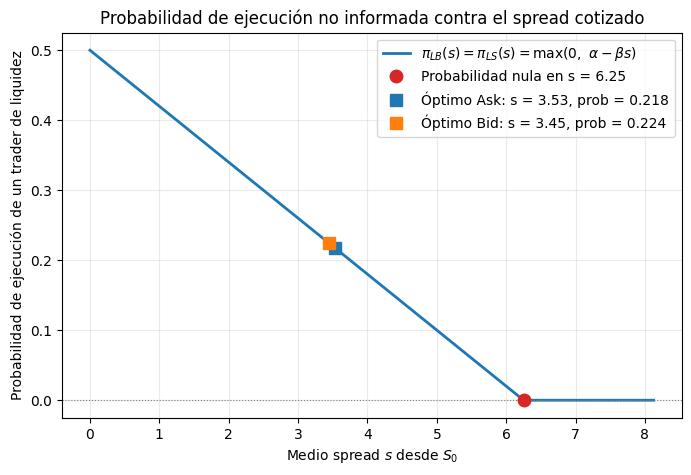

In [11]:
choke = 0.50 / 0.08         # medio spread donde la probabilidad de ejecucion llega a cero

s = np.linspace(0, choke * 1.3, 400)
prob = [prob_ejecucion(x) for x in s]     # prob_ejecucion usa max(), no vectoriza

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(s, prob, lw=2, color="#1f77b4",
        label=r"$\pi_{LB}(s) = \pi_{LS}(s) = \max(0,\ \alpha - \beta s)$")
ax.plot([choke], [0], "o", ms=9, color="#d62728", zorder=5,
        label=f"Probabilidad nula en s = {choke:.2f}")

for lado, s_lado in [("Ask", A_opt - So), ("Bid", So - B_opt)]:
    ax.plot([s_lado], [prob_ejecucion(s_lado)], "s", ms=8, zorder=5,
            label=f"Óptimo {lado}: s = {s_lado:.2f}, prob = {prob_ejecucion(s_lado):.3f}")

ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Medio spread $s$ desde $S_0$")
ax.set_ylabel("Probabilidad de ejecución de un trader de liquidez")
ax.set_title("Probabilidad de ejecución no informada contra el spread cotizado")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### Figura 2: P&L acumulado a lo largo de los 10,000 trades

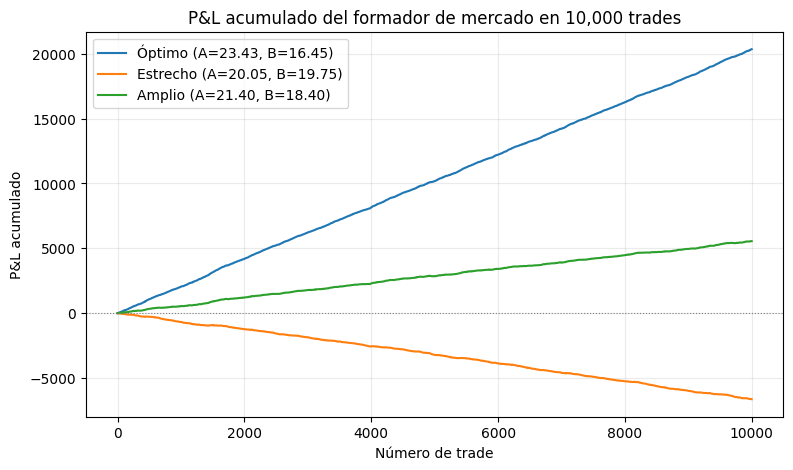

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

for nombre, d in sim.items():
    A, B = regimenes[nombre]
    ax.plot(d.index, d["pnl_acumulado"], lw=1.5,
            label=f"{nombre} (A={A:.2f}, B={B:.2f})")

ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Número de trade")
ax.set_ylabel("P&L acumulado")
ax.set_title("P&L acumulado del formador de mercado en 10,000 trades")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

### Figura 3: inventario acumulado a lo largo de los 10,000 trades

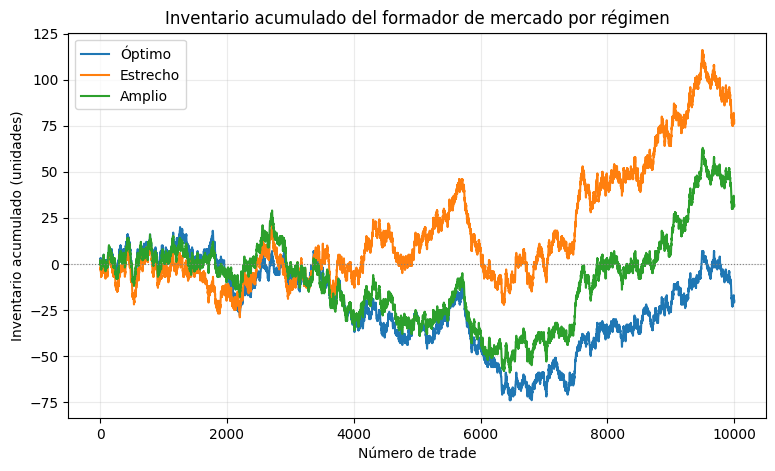

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

for nombre, d in sim.items():
    ax.plot(d.index, d["inventario_acumulado"], lw=1.5, label=nombre)

ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Número de trade")
ax.set_ylabel("Inventario acumulado (unidades)")
ax.set_title("Inventario acumulado del formador de mercado por régimen")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

El inventario final de **una** corrida es ruidoso: el trader de liquidez elige lado al azar, así
que el inventario es en buena medida una caminata aleatoria. Para responder *cuál régimen acumula
el mayor desbalance* sin depender de una sola semilla, se mide sobre 1,000 corridas.

In [ ]:
inv = {nombre: inventario_corridas(A, B, 1_000, N_TRADES)
       for nombre, (A, B) in regimenes.items()}

# Deriva teorica: solo el informado desbalancea de forma sistematica. Queda largo cuando el informado vende mas seguido de lo que compra.
dist = erlang(K, scale=1 / Lam)

resumen_inv = pd.DataFrame([
    {
        "Régimen": nombre,
        "Trades ejecutados": int((sim[nombre]["lado"] != 0).sum()),
        "Deriva teórica": N_TRADES * pi_i * (dist.cdf(regimenes[nombre][1])
                                             - dist.sf(regimenes[nombre][0])),
        "Inventario medio": v.mean(),
        "Desv. estándar": v.std(ddof=1),
        "|Inventario| medio": np.abs(v).mean(),
    }
    for nombre, v in inv.items()
]).set_index("Régimen")

resumen_inv.round(2)

,Trades ejecutados,Deriva teórica,Inventario medio,Desv. estándar,|Inventario| medio
Régimen,,,,,
Óptimo,6796,-76.17,-74.50,82.65,90.60
Estrecho,9820,13.15,16.05,97.57,80.09
Amplio,8272,-28.01,-24.58,91.39,75.82


**Sobre el inventario.** *El regimen se desbalancea más* 

- **Ruido (caminata aleatoria).** El trader de liquidez elige lado al azar, así que aporta pura
  varianza. Gana el **estrecho**: es el que más trades ejecuta (9,820 de 10,000, porque casi ningún
  informado se abstiene) y por eso tiene la desviación estándar de inventario más alta, ~98
  unidades. Más trades ejecutados, caminata más larga.
- **Deriva sistemática.** Solo el informado desbalancea de forma sostenida, y aquí gana el
  **óptimo**: sus cotizaciones están metidas en las colas de la Erlang, que es asimétrica a la
  derecha, así que la cola de arriba es más gorda que la de abajo. El informado compra al Ask el
  9.66% de las veces y vende al Bid solo el 7.76%, y el formador termina **corto** unas 75
  unidades. La columna *deriva teórica* —calculada como
  $n \cdot \pi_I \cdot [F(B) - (1 - F(A))]$— reproduce la simulación con menos de 4 unidades de
  diferencia en los tres regímenes.
- Sumando ambos efectos, el **óptimo** es el que más inventario carga en valor absoluto (~91
  unidades en promedio).

Ojo con el estrecho: su deriva es de apenas +13 unidades, prácticamente cero. No es que esté bien
balanceado por buen diseño, es coincidencia: con $A = 20.05$ y $B = 19.75$ el Ask y el Bid quedan
casi equidistantes de la **mediana** de $P$ (19.889), no de la media (20.00). En una corrida suelta
puede terminar largo o corto indistintamente.


## Analisis de sensibilidad 

In [19]:
#Creamos tabla con los resultados 

data = pd.DataFrame({
    'Ask óptimo (A)': [A_opt],
    'Bid óptimo (B)': [B_opt],
    'Utilidad esperada (U)': [utilidad]
})
data

,Ask óptimo (A),Bid óptimo (B),Utilidad esperada (U)
0,23.427664,16.45168,0.840285


In [20]:
# Creamos un analisis de sensibilidad con los valores para calcular +10% y -10%
spread_ask_opt = A_opt - So
spread_bid_opt = So - B_opt   # corregido: el medio spread del Bid es positivo

Spread_ask_mas10 = So + spread_ask_opt * 1.10
Spread_bid_mas10 = So - spread_bid_opt * 1.10

Spread_ask_menos10 = So + spread_ask_opt * 0.90
Spread_bid_menos10 = So - spread_bid_opt * 0.90

regimenes["Óptimo +10%"] = (Spread_ask_mas10, Spread_bid_mas10)
regimenes["Óptimo -10%"] = (Spread_ask_menos10, Spread_bid_menos10)


for nombre in ["Óptimo", "Óptimo +10%", "Óptimo -10%"]:
    A, B = regimenes[nombre]
    print(f"{nombre}: A={A:.2f}, B={B:.2f}, spread={A-B:.2f}, Pi teórica={Pi(A,B):.4f}")

print()

for nombre in ["Óptimo", "Óptimo +10%", "Óptimo -10%"]:
    A, B = regimenes[nombre]
    pnl_finales = simular_corridas(A, B, 1_000, 1_000, seed=7)
    print(f"{nombre:14s} | P&L prom={pnl_finales.mean():10.2f} | std={pnl_finales.std():8.2f} | "
          f"P(pérdida)={np.mean(pnl_finales < 0):.4f}")

Óptimo: A=23.43, B=16.45, spread=6.98, Pi teórica=0.8403
Óptimo +10%: A=23.78, B=16.11, spread=7.67, Pi teórica=0.8258
Óptimo -10%: A=23.07, B=16.80, spread=6.28, Pi teórica=0.8254

Óptimo         | P&L prom=   2009.60 | std=   86.15 | P(pérdida)=0.0000
Óptimo +10%    | P&L prom=   2240.34 | std=   89.01 | P(pérdida)=0.0000
Óptimo -10%    | P&L prom=   1772.83 | std=   83.57 | P(pérdida)=0.0000


## Analisis Montecarlo

1,000 corridas independientes de 1,000 trades cada una, para los tres regímenes. De cada corrida se
guarda únicamente el P&L final, y sobre esa distribución se reporta el promedio, la desviación
estándar y la probabilidad de pérdida (proporción de corridas que terminan en negativo).

In [22]:
N_CORRIDAS = 1_000
N_TRADES_MC = 1_000

mc = {nombre: simular_corridas(*regimenes[nombre], N_CORRIDAS, N_TRADES_MC)
      for nombre in REGIMENES_BASE}

resumen_mc = pd.DataFrame([
    {
        "Régimen": nombre,
        "P&L promedio": pnl.mean(),
        "Desv. estándar": pnl.std(ddof=1),
        "P(pérdida)": (pnl < 0).mean(),
        "P&L por trade": pnl.mean() / N_TRADES_MC,
    }
    for nombre, pnl in mc.items()
]).set_index("Régimen")

resumen_mc.round(4)

,P&L promedio,Desv. estándar,P(pérdida),P&L por trade
Régimen,,,,
Óptimo,2008.6002,87.1417,0.0,2.0086
Estrecho,-672.6975,77.5796,1.0,-0.6727
Amplio,542.9112,77.9382,0.0,0.5429


### Figura 4: distribución del P&L final de las 1,000 corridas

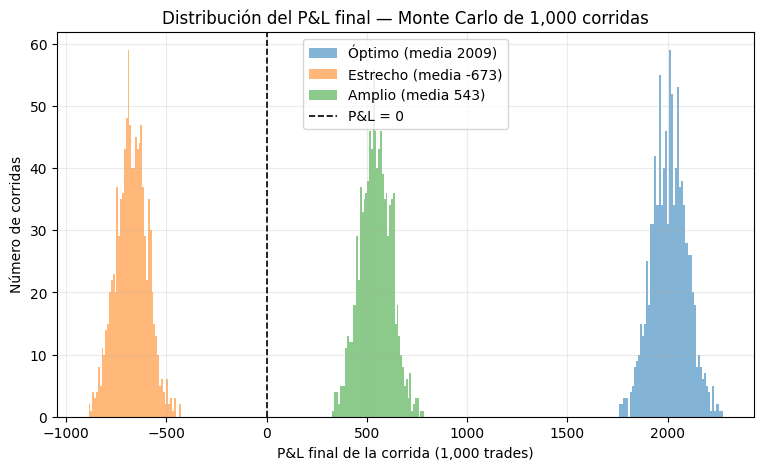

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

for nombre, pnl in mc.items():
    ax.hist(pnl, bins=50, alpha=0.55, label=f"{nombre} (media {pnl.mean():.0f})")

ax.axvline(0, color="black", lw=1.2, ls="--", label="P&L = 0")
ax.set_xlabel("P&L final de la corrida (1,000 trades)")
ax.set_ylabel("Número de corridas")
ax.set_title("Distribución del P&L final — Monte Carlo de 1,000 corridas")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

**Lectura del Monte Carlo.** Las tres distribuciones quedan bien separadas: con 1,000 trades por
corrida la dispersión es chica frente a la distancia entre medias. El régimen estrecho tiene
probabilidad de pérdida prácticamente 1 y el amplio prácticamente 0; no es que uno sea "más
riesgoso" que el otro, es que uno tiene esperanza negativa por trade y el otro positiva.

## Sensibilidad al parámetro $\pi_I$ (sección 3.5)

Se repite la optimización para $\pi_I \in \{0.1, 0.4, 0.7\}$, manteniendo $\pi_L = 1 - \pi_I$.

In [24]:
def optimizar_con_pi_i(valor):
    """Reoptimiza (A, B) para otro pi_i.

    Pi() lee pi_i y pi_l como globales, así que se cambian temporalmente y se restauran.
    """
    global pi_i, pi_l
    pi_i_original, pi_l_original = pi_i, pi_l
    pi_i, pi_l = valor, 1 - valor
    try:
        res = opt.minimize(objetivo, x0=[So + 0.10, So - 0.10], bounds=bounds)
        A, B = res.x
        return A, B, Pi(A, B)
    finally:
        pi_i, pi_l = pi_i_original, pi_l_original


valores_pi_i = [0.1, 0.4, 0.7]

filas = []
for valor in valores_pi_i:
    A, B, utilidad_pi = optimizar_con_pi_i(valor)
    filas.append({
        "pi_I": valor,
        "Ask": A,
        "Bid": B,
        "Spread": A - B,
        "Utilidad esperada": utilidad_pi,
    })

sensibilidad = pd.DataFrame(filas).set_index("pi_I")
sensibilidad.round(4)

,Ask,Bid,Spread,Utilidad esperada
pi_I,,,,
0.1,23.1065,16.7088,6.3977,1.3787
0.4,23.4277,16.4517,6.9760,0.8403
0.7,24.0008,16.0070,7.9939,0.3366


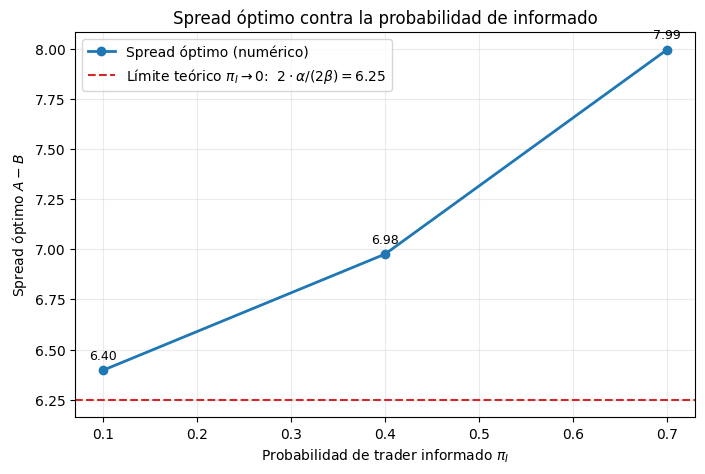

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(sensibilidad.index, sensibilidad["Spread"], "o-", lw=2, color="#1f77b4",
        label="Spread óptimo (numérico)")
ax.axhline(2 * 0.50 / (2 * 0.08), color="#d62728", ls="--", lw=1.5,
           label=r"Límite teórico $\pi_I \to 0$:  $2 \cdot \alpha/(2\beta) = 6.25$")

for x, y in zip(sensibilidad.index, sensibilidad["Spread"]):
    ax.annotate(f"{y:.2f}", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9)

ax.set_xlabel(r"Probabilidad de trader informado $\pi_I$")
ax.set_ylabel("Spread óptimo $A - B$")
ax.set_title("Spread óptimo contra la probabilidad de informado")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

**Contraste con la teoría.** La predicción es que el spread es creciente en $\pi_I$: entre más
probable es que quien llega esté informado, más caro sale cotizar cerca de $S_0$ y más se abre el
formador. La tabla lo confirma.

El límite analítico también sale. Cuando $\pi_I \to 0$ el problema se vuelve el del monopolista
puro, la utilidad por lado queda $\pi_L(\alpha - \beta s)s$ y su máximo está donde
$\alpha - 2\beta s = 0$:

$$s^{*} = \frac{\alpha}{2\beta} = \frac{0.50}{0.16} = 3.125
\quad\Rightarrow\quad \text{spread} = 2s^{*} = 6.25.$$

> **Ojo con el enunciado.** La sección 3.6 del PDF dice que ese óptimo es $s^{*} = 0.50/0.08 =
> 6.25$ **por lado**. Ese número no es el máximo: es el punto donde $\alpha - \beta s = 0$, o sea
> donde la probabilidad de ejecución se anula y la utilidad vale exactamente **cero**. El máximo
> real está en la mitad, $s^{*} = 3.125$ por lado. Conviene mencionarlo en la exposición en vez de
> dejarlo pasar.

## Limitaciones del modelo

La simulación fuerza la ejecución de un trade en cada iteración: los traders de liquidez siempre operan, 
sin pasar por $\pi_{LB}(s) = \max(0,\ 0.50 - 0.08 s)$. Por eso los resultados son **rentabilidad por trade
ejecutado**, no por unidad de tiempo, y un régimen muy amplio —que en la realidad casi nunca se
ejecutaría— sale favorecido. La utilidad teórica $\Pi = 0.84$ sí incorpora esa probabilidad; el
P&L por trade de la simulación no. No son comparables directamente.

**Limitaciones del model:**

1. **No hay gestión de inventario ni riesgo de posición.** El modelo es de un solo periodo y valúa
   cada trade aislado contra $P$. En la práctica el formador sesga (*skew*) sus cotizaciones según
   el inventario que carga, y una posición corta grande como la que acumula el régimen estrecho
   consume capital y expone a riesgo de precio.
2. **$\pi_I$ es constante** El formador reacciona ampliando el spread justo en esos momentos.
   Aquí $\pi_I$ no depende ni del tiempo ni del spread cotizado.
3. **No hay competencia ni microestructura del libro.** El formador es monopolista, cotiza tamaño
   uno, no hay tick size, ni cola de prioridad, ni la posibilidad de que otro participante mejore
   el precio. Con competencia el spread de equilibrio colapsa hacia el costo de selección adversa
   puro, mucho menor que el 6.98 que sale aquí.